In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
from jax import config
config.update("jax_enable_x64", False)

In [2]:
n_states, start_width, threshold, measurement_prob, delta, mu, sigma, I, J = 7, 3, 1, 1, 1, np.asarray([[2]]), np.asarray([[1]]), 1, 5
model_type, transition_type = "Markov", "TIMESTEP"

In [3]:
I = 10
mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
phi_0 = ca._get_initial_state(n_states, start_width,model_type=model_type, prior_type="Uniform")
intensity_matrix, phi_0

(Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]],
 
 
        [[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]],
 
 
        [[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,

In [4]:
jax.jacrev(ca.get_intensity_matrix, allow_int=True)(n_states, mu, sigma, model_type).size

490

In [5]:
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
Mc

Array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [6]:

t = np.asarray([[20]]) #t_s #
phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=t, RA_s = None, delta=delta, 
Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
transition_type=transition_type, likelihood_type="SINGLE")

intensity_matrix.size, phi_t.size, (phi_t.size * phi_t.itemsize) / 1000000 # to get MB

(490, 70, 0.00028)

In [7]:
phi_jac = jax.jacfwd(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(490, 34300, 0.1372)

In [8]:
intensity_matrix.squeeze().shape, phi_t.squeeze().shape, phi_jac.squeeze().shape

((10, 7, 7), (10, 7), (10, 7, 10, 7, 7))

In [9]:
import jax.scipy as sci

In [12]:
ns=np.ceil(t/delta)

def perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT"):
     
    #ns=np.floor(RT/delta) # uncomment to include all response time
    
    T_delta = sci.linalg.expm(intensity_matrix * delta)

    # uncomment to include all response time
    # T_delta_remaining = sci.linalg.expm(intensity_matrix * ((RT_remaining[...,None,None]) if not npx.isscalar(RT_remaining) else (RT_remaining)))
    T_t = ca._timestep_transition_matrix(ns, T_delta, Mn)  #uncomment if fails
    return T_t

In [13]:
fn = jax.jacrev(perform_state_transition)
compiled = jax.jit(fn, static_argnames=["transition_type", "likelihood_type"]).lower(intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, transition_type, "SINGLE"
     )
compiled.compile().cost_analysis()

[{'bytes accessed4{}': 4808440.0,
  'bytes accessed5{}': 2885790.0,
  'bytes accessed10{}': 40.0,
  'utilization0{}': 362.5714416503906,
  'bytes accessed0{}': 43343296.0,
  'bytes accessed11{}': 4.0,
  'bytes accessed6{}': 962564.0,
  'utilization7{}': 6.0,
  'flops': 50408256.0,
  'transcendentals': 20.0,
  'utilization2{}': 150.0,
  'bytes accessed3{}': 7688384.0,
  'bytes accessed7{}': 960520.0,
  'utilization4{}': 79.0,
  'utilization1{}': 252.0,
  'utilization3{}': 103.0,
  'utilization5{}': 19.0,
  'utilization11{}': 1.0,
  'optimal_seconds': -22.0,
  'bytes accessed1{}': 31068576.0,
  'utilization6{}': 10.0,
  'utilization8{}': 1.0,
  'bytes accessed2{}': 13945095.0,
  'bytes accessedout{}': 50457332.0,
  'utilization9{}': 1.0,
  'bytes accessed8{}': 960400.0,
  'bytes accessed9{}': 960400.0,
  'bytes accessed': 152436048.0,
  'utilization10{}': 1.0}]

In [14]:
phi_jac = jax.jacrev(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(490, 34300, 0.1372)

In [15]:
intensity_matrix.shape, phi_jac.shape

((10, 1, 7, 7), (10, 1, 7, 1, 10, 1, 7, 7))

In [16]:
jax.jacfwd(jax.jacrev(ca.perform_state_transition))\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE").size

16807000

In [17]:
likl = jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)
likl.shape

(10, 1, 10, 1, 7, 7)

In [18]:
likl_lower = jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)

In [19]:
import jax.numpy as npx
def likelihood(intensity_matrix, phi_0, delta, RT_s, RA_s, Mc, Mw, Mn, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT", model_type="Markov|Quantum"):

    phi_t = perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, 
                                     transition_type=transition_type, likelihood_type=likelihood_type)

    if likelihood_type == "SINGLE":
        RA = RA_s
        RT_cond = RT_s
    else:
        raise Exception(f"Please select one of {likelihood_type} values for likelihood_type variable")


    P_t_c = (Mc @ phi_t)
    P_t_w = (Mw @ phi_t)
    P_t = npx.where(RA[...,None,None]==1, P_t_c, P_t_w)

    if model_type == "Markov":
        #P_t_c = (Mc @ phi_t).sum(axis=(-2,-1))
        #P_t_w = (Mw @ phi_t).sum(axis=(-2,-1))

        P_t = P_t.sum(axis=(-2,-1)) # Adding over states
        
        #P_t = npx.where(RA==1, P_t_c, P_t_w)
        
    elif model_type == "Quantum":
        #P_t_c = (npx.abs(Mc @ phi_t)**2).sum(axis=(-2,-1))
        #P_t_w = (npx.abs(Mw @ phi_t)**2).sum(axis=(-2,-1))

        P_t = (npx.abs(P_t)**2).sum(axis=(-2,-1)) #Adding over states
        

        #P_t = npx.where(RA==1, P_t_c, P_t_w)
        
    else:
        raise Exception(f"Please select one of {model_type}")
  
    
    P_t = npx.where(RT_cond <= 0, 0, P_t)

    return P_t #npx.log(npx.sum(P_t)) # summing over all participants and trials

In [20]:
fn = jax.jacrev(likelihood)
cost = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).compile().cost_analysis()
cost

[{'utilization0{}': 338.57147216796875,
  'bytes accessed8{}': 19600.0,
  'bytes accessed9{}': 19600.0,
  'bytes accessed10{}': 40.0,
  'bytes accessed5{}': 63390.0,
  'flops': 2706025.0,
  'transcendentals': 20.0,
  'utilization2{}': 154.0,
  'bytes accessed11{}': 4.0,
  'bytes accessed6{}': 21764.0,
  'bytes accessed0{}': 1428708.0,
  'utilization7{}': 6.0,
  'utilization4{}': 79.0,
  'bytes accessed3{}': 161984.0,
  'utilization1{}': 256.0,
  'bytes accessed7{}': 19720.0,
  'utilization3{}': 103.0,
  'utilization5{}': 19.0,
  'utilization11{}': 1.0,
  'bytes accessed1{}': 749185.0,
  'optimal_seconds': -1.0,
  'bytes accessed2{}': 358855.0,
  'bytes accessedout{}': 1689733.0,
  'utilization6{}': 10.0,
  'utilization8{}': 1.0,
  'bytes accessed4{}': 104440.0,
  'utilization10{}': 1.0,
  'bytes accessed': 4581627.0,
  'utilization9{}': 1.0}]

In [28]:
import itertools as iter
n_states_arr, start_width_arr, delta, measurement_prob,  = [11, 51, 101], [2, 7, 11], 0.5, 0.8
threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [20, 200, 2000], [50] #,1000,10000
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov", "Quantum"]
df_memory = []
for (n_states, start_width), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    
    mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
    Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
    phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    
    #fn_g = jax.jacrev(perform_state_transition, holomorphic=True if model_type=="Quantum" else False)
    #fn_g_jit = jax.jit(fn_g, static_argnames=["delta", "transition_type", "likelihood_type"])
    #cost_st_tr_g = fn_g_jit.lower(intensity_matrix, t, None, 
    #        Mc, Mw, Mn, 
    #        phi_0, delta, transition_type, "SINGLE"
    #        ).cost_analysis()
    
    fn_g = jax.jacrev(likelihood)
    cost_st_tr_g = jax.jit(fn_g, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).compile().cost_analysis()[0]

    
    fn_s = perform_state_transition
    fn_s_jit = jax.jit(fn_s, static_argnames=["delta", "transition_type", "likelihood_type"])
    cost_st_tr_s = fn_s_jit.lower(intensity_matrix, t, None, 
            Mc, Mw, Mn, 
            phi_0, delta, transition_type, "SINGLE"
            ).compile().cost_analysis()[0]

    fn = likelihood
    cost_st_tr = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).compile().cost_analysis()[0]


    df_t = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        "States":n_states,
        "bytes_accessed_g": [cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        "flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed_s": [cost_st_tr_s["bytes accessed"] / 1000000000], # to get GB
        "flops_s": [cost_st_tr_s["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory.append(df_t)
df_memory = pd.concat(df_memory)
df_memory

11 2 20 50 TIMESTEP Markov
0.001693165 0.039339376
11 2 20 50 TIMESTEP Quantum
0.003355061 0.09531952
11 2 200 50 TIMESTEP Markov
0.014783958 3.479781632
11 2 200 50 TIMESTEP Quantum
0.03328762 8.942465024
11 2 2000 50 TIMESTEP Markov
0.147724736 323.243114496
11 2 2000 50 TIMESTEP Quantum
0.332613184 888.394022912
51 7 20 50 TIMESTEP Markov
0.014582534 0.494142912
51 7 20 50 TIMESTEP Quantum
0.039595972 1.467625728
51 7 200 50 TIMESTEP Markov
0.130960928 46.083555328
51 7 200 50 TIMESTEP Quantum
0.390427456 138.266853376
51 7 2000 50 TIMESTEP Markov
1.307541888 4580.817502208
51 7 2000 50 TIMESTEP Quantum
3.898742272 13742.609793024
101 11 20 50 TIMESTEP Markov
0.051930844 1.91597248
101 11 20 50 TIMESTEP Quantum
0.154909456 5.755537408
101 11 200 50 TIMESTEP Markov
0.5112216 180.734738432
101 11 200 50 TIMESTEP Quantum
1.52741952 542.2718976
101 11 2000 50 TIMESTEP Markov
4.93768192 17965.552500736
101 11 2000 50 TIMESTEP Quantum
15.252519936 53897.846587392


,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed_s,flops_s,bytes_accessed,flops
0,Markov,Internal,20,50,11,0.039339,0.013880,0.001634,0.000708,0.001693,0.000819
0,Quantum,Internal,20,50,11,0.095320,0.036826,0.003234,0.000708,0.003355,0.000824
0,Markov,Internal,200,50,11,3.479782,0.817094,0.014201,0.003169,0.014784,0.004282
0,Quantum,Internal,200,50,11,8.942465,3.533126,0.032120,0.006896,0.033288,0.008058
0,Markov,Internal,2000,50,11,323.243114,71.242818,0.141908,0.031504,0.147725,0.042636
0,Quantum,Internal,2000,50,11,888.394023,351.835947,0.320984,0.068774,0.332613,0.080391
0,Markov,Internal,20,50,51,0.494143,0.224496,0.012896,0.011351,0.014583,0.022097
0,Quantum,Internal,20,50,51,1.467626,3.164673,0.036578,0.059108,0.039596,0.069963
0,Markov,Internal,200,50,51,46.083555,14.927989,0.122631,0.042981,0.130961,0.044320
0,Quantum,Internal,200,50,51,138.266853,303.829385,0.361185,0.573588,0.390427,0.682094


phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    phi_jac = jax.jacfwd(ca.perform_state_transition, holomorphic=True if model_type=="Quantum" else False)(intensity_matrix, random_ts, None, delta, 
    Mc, Mn, Mw, phi_0, transition_type, "SINGLE")

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Memory(GB)") \
            .assign(**{"Memory(GB)": lambda df: df["Memory(GB)"].map({"bytes_accessed_g":"Jacobian of Transition Fn", "bytes_accessed":"Transition Function"})})
            ,
style="States",
y="value",
col="Model",
x="I",
hue="Memory(GB)",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log", xscale="log")
f.set_ylabels("Memory (GB)")
f.set_xlabels("Number of Participants")
f.set_titles(col_template="{col_name}")

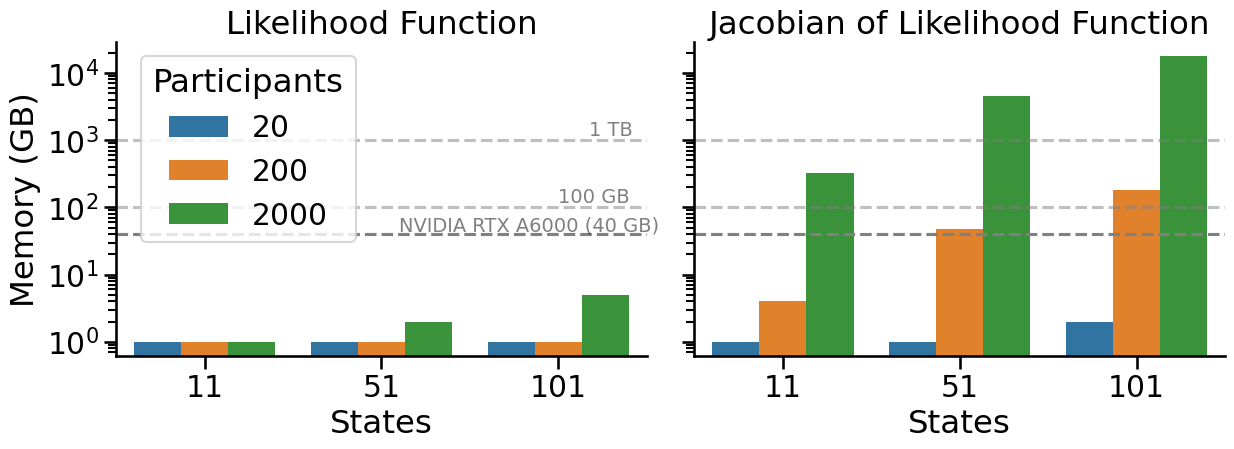

In [34]:
with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory.query("Model=='Markov'").melt(id_vars=df_memory.columns.drop(["bytes_accessed_s", "bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_s":"Transition Function", "bytes_accessed_g":"Jacobian of Likelihood Function", "bytes_accessed":"Likelihood Function"})})
                .assign(I = lambda df: df.I.astype(str), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Likelihood Function", "Jacobian of Likelihood Function"],
    kind="bar", #facet_kws={"sharey":True}
    )
    f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    f.refline(y=1000, alpha=0.5)
    f.refline(y=100, alpha=0.5)
    f.refline(y=40)
    f.legend.set_title("Participants")
    f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.2)
    f.legend.set_frame_on(True)

    
    f.axes[0,0].text(y=120, x=2, s="100 GB", alpha=0.5, size=14)
    f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

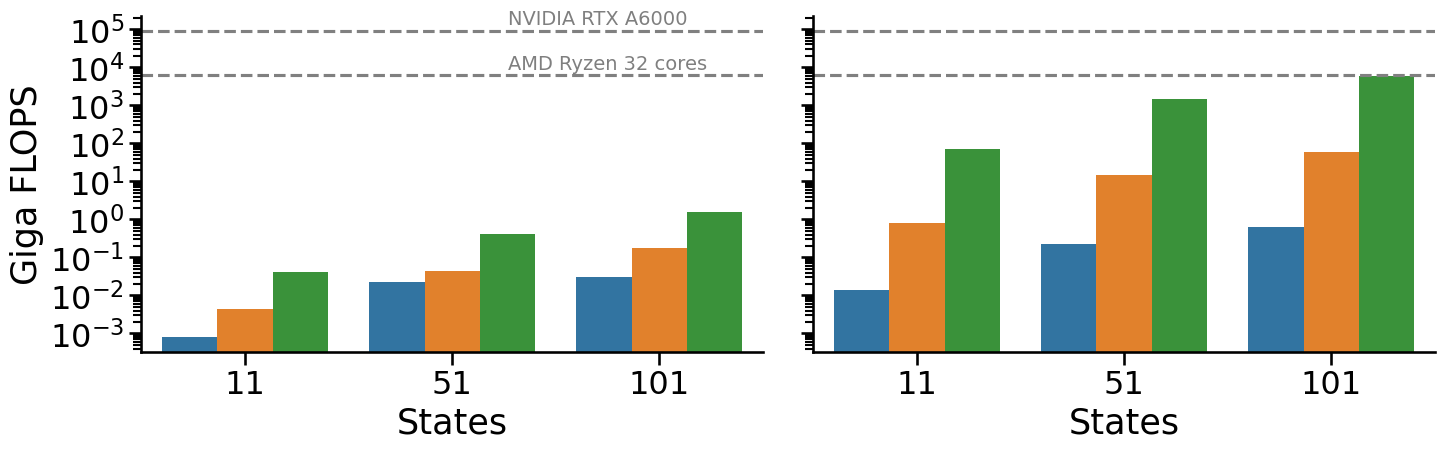

In [33]:
with sns.plotting_context("talk", font_scale=1.4):
    f = sns.catplot(
                df_memory.query("Model=='Markov'").melt(id_vars=df_memory.columns.drop(["flops_g", "flops_s", "flops"]), var_name="FLOPS") \
                .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Likelihood Function", "flops":"Likelihood Function", "flops_s":"Transition Function"})) 
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    hue="I", col_order=["Likelihood Function", "Jacobian of Likelihood Function"],
    col="FLOPS",
    kind="bar", aspect=1.5, legend=False
    )
    f.set(yscale="log")
    f.set_ylabels("Giga FLOPS")
    f.set_xlabels("States")
    f.set_titles(col_template="")
    f.refline(y=91.1*1000) #91.1 TFLOPS
    f.refline(y=6451.2) # AMD Threadripper
    #f.legend.set_title("Participants")
    f.axes[0,0].text(y=91.1*1500, x=1.27, s="NVIDIA RTX A6000", alpha=0.5, size=14)
    f.axes[0,0].text(y=8900, x=1.27, s="AMD Ryzen 32 cores", alpha=0.5, size=14) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
            .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Fn", "flops":"Transition Function"})) 
            ,
style="States",
y="value",
col="Model",
x="I",
hue="FLOPS",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log")